# Data Literacy
#### University of Tübingen, Winter 2025/26
## Lecture 06 -- Can I eat this?

---
&copy; Philipp Hennig, 2025. [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/)

In [15]:
%run -i '../../preamble.py'
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly import colors
from scipy.sparse.linalg import svds

In this lecture we will use two food composition datasets from [Danish](https://frida.fooddata.dk/data?lang=en) and [Swedish](https://www.livsmedelsverket.se/en/food-and-content/naringsamnen/livsmedelsdatabasen/) institutions. More databases can be found at [langual.org](langual.org)

In [16]:
Danish = pd.read_excel(
    "dat/Frida_Dataset_May2025.xlsx",
    sheet_name="Data_Table",
    skiprows=0,
    header=[1, 2, 3],
)


# the Danish dataset has a complicated Multi-Index. Let's flatten it for easier comparison below:
units = Danish.columns.get_level_values(1)

Danish.columns = [f"{col[0]}" for col in Danish.columns]

# rename first two columns:
Danish.columns = ["FødevareNavn", "FoodName", "FoodID"] + [
    f"{col}" for col in Danish.columns[3:]
]
print(f"{len(Danish)} food items in the Danish database")
Danish.head()

1370 food items in the Danish database


,FødevareNavn,FoodName,FoodID,Energy (kJ),"Energy, labelling (kJ)",Energy (kcal),"Energy, labelling (kcal)",Protein,Protein from Amino Acids,"Protein, labeling",...,Sum biogenic amines,Waste,Nitrogen conversion factor,Fatty acid conversion factor,Density,pH,pH,pH,pH,pH
0,"Jordbær, rå","Strawberry, raw",1,161.953590,148.426875,38.457949,35.275192,0.659856,0.473128,0.659856,...,0.013,3.91,6.25,0.800,NaN,NaN,51,Bærfrugt,Soft fruit,A0833
1,"Æble, uspec., råt","Apple, raw, all varieties",2,232.547830,220.141493,55.064734,52.145595,0.269358,0.189219,0.269358,...,10.092,9.70,6.25,0.800,NaN,NaN,49,Kernefrugt,Pome fruit,A0833
2,"Banan, rå","Banana, raw",3,396.194566,374.981856,93.475466,88.484240,1.140625,0.738623,1.140625,...,NaN,40.72,6.25,0.730,NaN,NaN,52,Sydfrugt,Tropical or subtropical fruit,A0833
3,"Kartoffel, uspec., rå","Potato, raw",4,326.336428,360.862595,77.039895,85.163699,2.026890,1.530354,2.026890,...,NaN,25.20,6.25,0.800,NaN,NaN,39,Rod- og knoldgrøntsager,Root and tuber vegetables,A0829
4,"Sødmælk, konventionel (ikke-økologisk)","Milk, whole, konventional (not organic), 3.5 %...",6,263.796404,265.949180,63.077242,63.583777,3.421768,3.082914,3.352045,...,0.040,0.00,6.38,0.945,1.031,NaN,4,Usyrnede mælkeprodukter,Unfermented milk products,A0780


In [17]:
for i, col in enumerate(Danish.columns):
    print(f"{i:2d}: {col} {Danish[col].max()}, {Danish[col].min()}")

 0: FødevareNavn Østers, rå, A38, acidophilus tykmælk af letmælk, 1,5% fedt
 1: FoodName Yogurt, with fruit, 1.5 % fat, Alfalfa seeds
 2: FoodID 1981, 1
 3: Energy (kJ) 3700.0, 0.0
 4: Energy, labelling (kJ) 3700.0, 0.0
 5: Energy (kcal) 900.0, 0.0
 6: Energy, labelling (kcal) 900.0, 0.0
 7: Protein 86.9, 0.0
 8: Protein from Amino Acids 73.0344794987488, 0.0
 9: Protein, labeling 86.9, 0.0
10: Carbohydrate by difference 100.0, 0.0
11: Available carbohydrates 100.0, 0.0
12: Available carbohydrate, labelling 100.0, 0.0
13: Dietary fibre 55.8, 0.0
14: Fat 162.2, 0.0
15: Alcohol 39.7, 0.0
16: Salt labelling 97.125, 0.0
17: Ash 99.8, 0.0
18: Dry matter 385.4, 0.0
19: Water 100.0, 0.0
20: Vitamin A 60000.0, 0.0
21: Retinol 60000.0, 0.0
22: beta-Carotene 12770.0, 0.0
23: cis-beta-Caroten 97.3, 0.0
24: Vitamin D 500.0, 0.0
25: Vitamin D3 500.0, 0.0
26: Vitamin D2 14.2, 0.0
27: 25-hydroxy vitamin D3  1.062, 0.0
28: 25-hydroxy Vitamin D2 0.103333333333333, 0.0
29: Vitamin E 149.4, 0.0
30: alpha

In [18]:
# The Swedish Data has a simpler structure:
Swedish = pd.read_excel("dat/LivsmedelsDB_202506241453.xlsx", skiprows=[0, 1])
Swedish.head()

,Food Name,Food Number,Filter group,Energy (kcal),Energy (kJ),"Fat, total (g)",Protein (g),"Carbohydrates, available (g)",Fibre (g),Water (g),...,"Iodide, I (µg)","Iron, Fe (mg)","Calcium, Ca (mg)","Potassium, K (mg)","Magnesium, Mg (mg)","Sodium, Na (mg)","Salt, NaCl (g)","Selenium, Se (µg)","Zinc, Zn (mg)",Waste (e.g. peel) (%)
0,Beef tallow,1,"Fat, oil",656,2746,71.0,7.0,0.0,0.0,21.7,...,0.0,0.3,0,6,3,10,0.0,1.0,0.1,0.0
1,Pork lard 85% fat,2,"Fat, oil",763,3193,85.0,2.8,0.0,0.0,11.1,...,0.0,0.2,4,65,1,11,0.0,5.0,0.4,0.0
2,Pork leaf lard 100% fat,3,"Fat, oil",884,3700,100.0,0.0,0.0,0.0,0.0,...,0.0,0.1,1,1,1,2,0.0,7.0,0.1,0.0
3,Coconut fat,4,"Fat, oil",884,3700,100.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
4,Blended spread sea salt 80% fat fortified e.g....,5,"Fat, oil",712,2977,80.0,0.5,0.5,0.0,17.5,...,2.4,0.2,18,20,3,800,2.0,0.0,0.1,0.0


## Some exploratory data analysis.

A common zeroth-order approximation for "good food" is food that contains *few calories*, but is also *high in protein and fibre*.

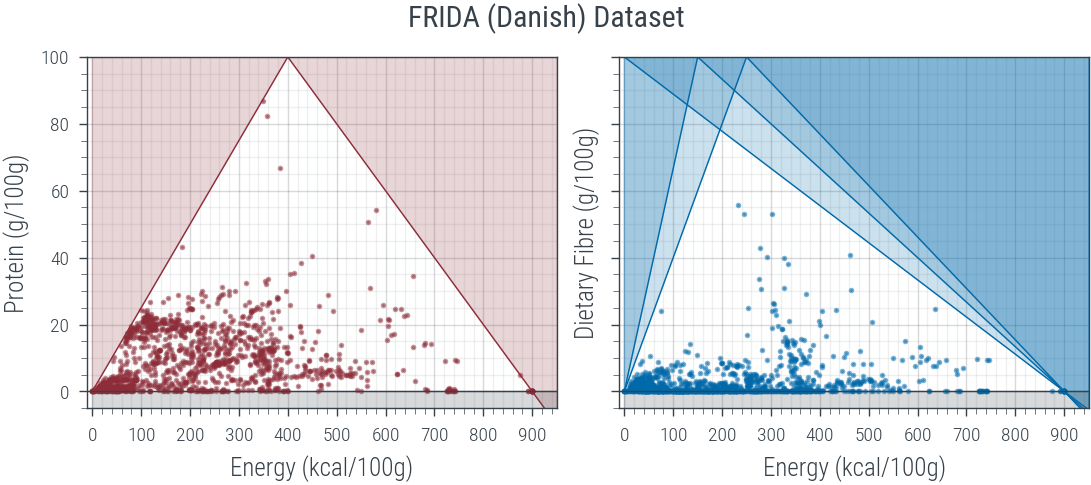

In [19]:
xenergy = np.linspace(0, 950, 100)
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
ax = axs[0]
ax.plot(
    Danish["Energy (kcal)"], Danish["Protein"], ".", color=rgb.tue_red, alpha=0.5, ms=2
)

# protein has 4 kcal per g, so something that gets all its energy from protein would have a protein density of 0.25 g/kcal:
ax.plot(xenergy, 0.25 * xenergy, color=rgb.tue_red, lw=0.5)
ax.fill_between(
    xenergy, np.ones_like(xenergy) * 1000, 0.25 * xenergy, color=rgb.tue_red, alpha=0.2
)
# and something that has a calorie density over 4 kcal/g must contain less than 100% protein. The highest energy density
# amont macronutrients is fat, at about 9 kcal/g. Hence: E <= 400 * P + 900 * (1 - P) = 900 - 500 * P, or P <= (900 - E) / 500
ax.plot(xenergy, (900 - xenergy) / 5, color=rgb.tue_red, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * 1000,
    (900 - xenergy) / 5,
    color=rgb.tue_red,
    alpha=0.2,
)
ax.axhline(0, color=rgb.tue_dark, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * (-200),
    np.zeros_like(xenergy),
    color=rgb.tue_dark,
    alpha=0.2,
)

ax.set_xlabel("Energy (kcal/100g)")
ax.set_ylabel("Protein (g/100g)")

ax = axs[1]
ax.plot(
    Danish["Energy (kcal)"],
    Danish["Dietary fibre"],
    ".",
    color=rgb.tue_blue,
    alpha=0.5,
    ms=2,
)

# fibre energy content is trickier. Perfectly indigestible fibre would have 0 dietary energy, but
# typical dietary fibre contains 1.5 to 2.5 kcal/g in energy

ax.plot(xenergy, xenergy / 1.5, color=rgb.tue_blue, lw=0.5)
ax.plot(xenergy, xenergy / 2.5, color=rgb.tue_blue, lw=0.5)
ax.fill_between(
    xenergy, np.ones_like(xenergy) * 1000, xenergy / 1.5, color=rgb.tue_blue, alpha=0.2
)
ax.fill_between(
    xenergy, np.ones_like(xenergy) * 1000, xenergy / 2.5, color=rgb.tue_blue, alpha=0.2
)
# And hence something that has more than 250 kcal/100g must contain something else than fibre:
ax.plot(xenergy, (900 - xenergy) / (9 - 1.5), color=rgb.tue_blue, lw=0.5)
ax.plot(xenergy, (900 - xenergy) / (9 - 2.5), color=rgb.tue_blue, lw=0.5)
ax.plot(xenergy, (900 - xenergy) / 9, color=rgb.tue_blue, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * 1000,
    (900 - xenergy) / 9,
    color=rgb.tue_blue,
    alpha=0.2,
)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * 1000,
    (900 - xenergy) / (9 - 1.5),
    color=rgb.tue_blue,
    alpha=0.2,
)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * 1000,
    (900 - xenergy) / (9 - 2.5),
    color=rgb.tue_blue,
    alpha=0.2,
)
ax.axhline(0, color=rgb.tue_dark, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * (-200),
    np.zeros_like(xenergy),
    color=rgb.tue_dark,
    alpha=0.2,
)

ax.set_xlabel("Energy (kcal/100g)")
ax.set_ylabel("Dietary Fibre (g/100g)")

fig.suptitle("FRIDA (Danish) Dataset")

for ax in axs:
    ax.set_xlim(-10, 950)
    ax.set_ylim(-5, 100)
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(100))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(20))
    ax.grid(which="major", color=rgb.tue_dark)
    ax.grid(which="minor", color=rgb.tue_gray)

plt.savefig("FRIDA_Protein_Fibre_Energy.pdf")

How about the same plot with Carbohydrates (which also have 4 kCal / g) and Fat (which has 9 kCal/g)?

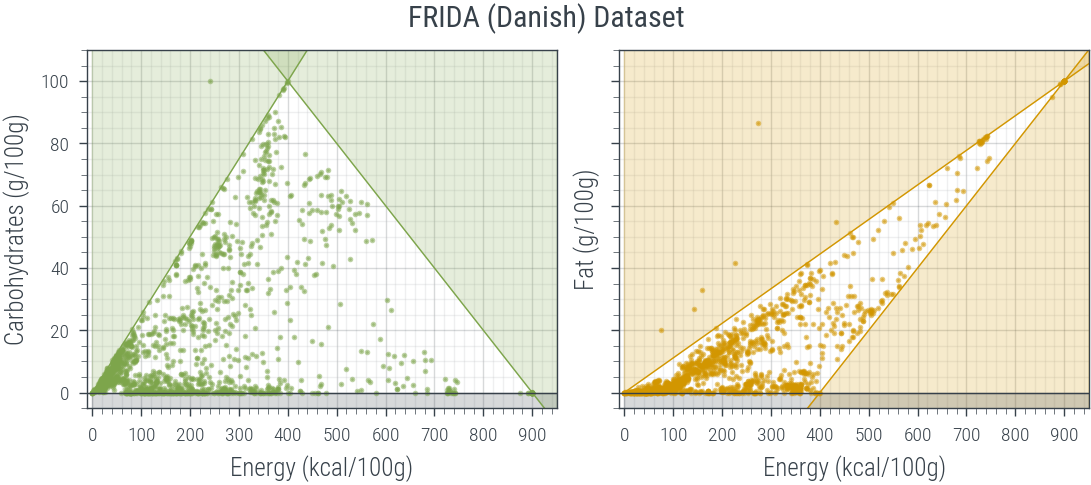

In [20]:
xenergy = np.linspace(0, 950, 100)
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True)
ax = axs[0]
ax.plot(
    Danish["Energy (kcal)"], Danish["Available carbohydrates"], ".", color=rgb.tue_green, alpha=0.5, ms=2
)

# carbohydrates have 4 kcal per g, so something that gets all its energy from carbohydrates would have a carbohydrate density of 0.25 g/kcal:
ax.plot(xenergy, 0.25 * xenergy, color=rgb.tue_green, lw=0.5)
ax.fill_between(
    xenergy, np.ones_like(xenergy) * 1000, 0.25 * xenergy, color=rgb.tue_green, alpha=0.2
)
# and something that has a calorie density over 4 kcal/g must contain less than 100% protein. The highest energy density
# amont macronutrients is fat, at about 9 kcal/g. Hence: E <= 400 * P + 900 * (1 - P) = 900 - 500 * P, or P <= (900 - E) / 500
ax.plot(xenergy, (900 - xenergy) / 5, color=rgb.tue_green, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * 1000,
    (900 - xenergy) / 5,
    color=rgb.tue_green,
    alpha=0.2,
)
ax.axhline(0, color=rgb.tue_dark, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * (-200),
    np.zeros_like(xenergy),
    color=rgb.tue_dark,
    alpha=0.2,
)

ax.set_xlabel("Energy (kcal/100g)")
ax.set_ylabel("Carbohydrates (g/100g)")

ax = axs[1]
ax.plot(
    Danish["Energy (kcal)"],
    Danish["Fat"],
    ".",
    color=rgb.tue_orange,
    alpha=0.5,
    ms=2,
)

# fat is even more fun: Fat has 9 kcal/g, so something that gets all its energy from fat would have a fat density of 0.111 g/kcal:

ax.plot(xenergy, xenergy / 9, color=rgb.tue_orange, lw=0.5)
ax.fill_between(
    xenergy, np.ones_like(xenergy) * 1000, xenergy / 9, color=rgb.tue_orange, alpha=0.2
)
# And now it's the other way around: Since all other macronutrients have at most 4 kcal/g, anything with over 400 kcal/100g must contain fat:
ax.plot(xenergy, (xenergy - 400) / (9-4), color=rgb.tue_orange, lw=0.5)
ax.fill_between(
    xenergy,
    (xenergy - 400) / (9-4),
    np.ones_like(xenergy) * (-1000),
    color=rgb.tue_orange,
    alpha=0.2,
)
ax.axhline(0, color=rgb.tue_dark, lw=0.5)
ax.fill_between(
    xenergy,
    np.ones_like(xenergy) * (-200),
    np.zeros_like(xenergy),
    color=rgb.tue_dark,
    alpha=0.2,
)

ax.set_xlabel("Energy (kcal/100g)")
ax.set_ylabel("Fat (g/100g)")

fig.suptitle("FRIDA (Danish) Dataset")

for ax in axs:
    ax.set_xlim(-10, 950)
    ax.set_ylim(-5, 110)
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(100))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(20))
    ax.grid(which="major", color=rgb.tue_dark)
    ax.grid(which="minor", color=rgb.tue_gray)

plt.savefig("FRIDA_Carb_Fat_Energy.pdf")

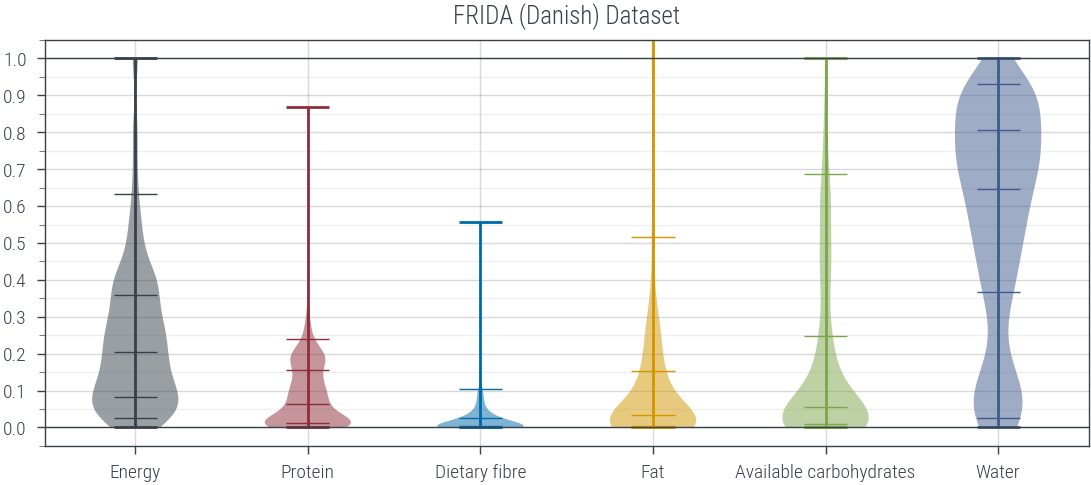

In [21]:
from scipy import stats

fig, ax = plt.subplots()
# for i,stat in enumerate(["Protein", "Energy (kcal)", "Fibre (g)"]):
parts = ax.violinplot(
    Danish["Energy (kcal)"].dropna() / 900,
    positions=[1],
    showmeans=False,
    showmedians=False,
    showextrema=True,
    widths=0.5,
    quantiles=[0.05, 0.25, 0.5, 0.75, 0.95],
    bw_method="silverman",
    points=200,
)
color=rgb.tue_dark
for part in parts["bodies"]:
    part.set_facecolor(color)
    part.set_alpha(0.5)
parts["cquantiles"].set_linewidth(0.5)
parts["cquantiles"].set_color(color)
parts["cbars"].set_color(color)
parts["cmaxes"].set_color(color)
parts["cmins"].set_color(color)

for i, stat, color in zip(
    range(2, 7),
    ["Protein", "Dietary fibre", "Fat", "Available carbohydrates", "Water"],
    [rgb.tue_red, rgb.tue_blue, rgb.tue_orange, rgb.tue_green, rgb.tue_darkblue],
):
    parts = ax.violinplot(
        Danish[stat].dropna() / 100,
        positions=[i],
        showmeans=False,
        showmedians=False,
        showextrema=True,
        widths=0.5,
        quantiles=[0.05, 0.25, 0.5, 0.75, 0.95],
        bw_method="silverman",
        points=200,
    )
    for part in parts["bodies"]:
        part.set_facecolor(color)
        part.set_alpha(0.5)
    parts["cquantiles"].set_linewidth(0.5)
    parts["cquantiles"].set_color(color)
    parts["cbars"].set_color(color)
    parts["cmaxes"].set_color(color)
    parts["cmins"].set_color(color)
    

ax.set_ylim(-0.05, 1.05)
ax.set_xticks(np.arange(1, 7))
ax.set_xticklabels(
    ["Energy", "Protein", "Dietary fibre", "Fat", "Available carbohydrates", "Water"]
)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.grid(which="major", color=rgb.tue_dark)
ax.grid(which="minor", color=rgb.tue_gray)
ax.set_title("FRIDA (Danish) Dataset")
ax.axhline(0, color=rgb.tue_dark, lw=0.5)
ax.axhline(1, color=rgb.tue_dark, lw=0.5)

plt.savefig("FRIDA_Protein_Fibre_Energy_Violin.pdf")

These point clouds have only limited value. We need an interactive plot!

In [22]:
# Find the correct column paths first
fig = go.Figure(
    data=go.Scatter(
        x=Danish["Energy (kcal)"],
        y=Danish["Protein"],
        mode="markers",
        marker=dict(
            size=5, opacity=0.6, color=color_from_rgb(rgb.tue_red), line=dict(width=0)
        ),
        text=Danish.iloc[:, 1],
        hovertemplate="<b>%{text}</b><br>"
        + "Energy: %{x:.1f} kcal<br>"
        + "Protein: %{y:.1f} g/100g<br>"
        + "<extra></extra>",
    ),
)

fig.update_layout(
    title="Protein vs Energy",
    xaxis_title="Energy (kCal)",
    yaxis_title="Protein (g/100g)",
    template=custom_template,
    xaxis=dict(dtick=100, range=[0, 1000]),
    yaxis=dict(dtick=10, range=[-2, 100]),
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig.show()

In [23]:
# Find the correct column paths first
fig = go.Figure(
    data=go.Scatter(
        x=Danish["Energy (kcal)"],
        y=Danish["Dietary fibre"],
        mode="markers",
        marker=dict(
            size=5, opacity=0.6, color=color_from_rgb(rgb.tue_blue), line=dict(width=0)
        ),
        text=Danish.iloc[:, 1],
        hovertemplate="<b>%{text}</b><br>"
        + "Energy: %{x:.1f} kcal<br>"
        + "Protein: %{y:.1f} g/100g<br>"
        + "<extra></extra>",
    ),
)

fig.update_layout(
    title="Dietary fibre vs Energy",
    xaxis_title="Energy (kcal)",
    yaxis_title="Dietary fibre (g/100g)",
    template=custom_template,
    xaxis=dict(dtick=100, range=[0, 1000]),
    yaxis=dict(dtick=10, range=[-2, 100]),
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig.show()

In [24]:
# Find the correct column paths first
fig = go.Figure(
    data=go.Scatter(
        x=Danish["Energy (kcal)"],
        y=Danish["Available carbohydrates"],
        mode="markers",
        marker=dict(
            size=5, opacity=0.6, color=color_from_rgb(rgb.tue_green), line=dict(width=0)
        ),
        text=Danish.iloc[:, 1],
        hovertemplate="<b>%{text}</b><br>"
        + "Energy: %{x:.1f} kcal<br>"
        + "Carbs: %{y:.1f} g/100g<br>"
        + "<extra></extra>",
    ),
)

fig.update_layout(
    title="Available carbohydrates vs Energy",
    xaxis_title="Energy (kcal)",
    yaxis_title="Available carbohydrates (g/100g)",
    template=custom_template,
    xaxis=dict(dtick=100, range=[0, 1000]),
    yaxis=dict(dtick=10, range=[-2, 105]),
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig.show()

In [25]:
# Find the correct column paths first
fig = go.Figure(
    data=go.Scatter(
        x=Danish["Energy (kcal)"],
        y=Danish["Fat"],
        mode="markers",
        marker=dict(
            size=5, opacity=0.6, color=color_from_rgb(rgb.tue_orange), line=dict(width=0)
        ),
        text=Danish.iloc[:, 1],
        hovertemplate="<b>%{text}</b><br>"
        + "Energy: %{x:.1f} kcal<br>"
        + "Fat: %{y:.1f} g/100g<br>"
        + "<extra></extra>",
    ),
)

fig.update_layout(
    title="Fat vs Energy",
    xaxis_title="Energy (kcal)",
    yaxis_title="Fat (g/100g)",
    template=custom_template,
    xaxis=dict(dtick=100, range=[0, 1000]),
    yaxis=dict(dtick=10, range=[-2, 105]),
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig.show()

In [26]:
Body_Mass = 75  # kg
Energy_Requirement = 2000  # kCal
Protein_Rate = 0.8  # g Protein / kg Body Mass
Fibre_Requirement = 30  # g Fibre / day
Protein_Requirement = Body_Mass * Protein_Rate

print(f"To get your recommended protein while within {Energy_Requirement} kCal per day, you need to eat food with a protein density above {Protein_Requirement / Energy_Requirement:.1e} g/kCal")
print(f"To get your recommended fibre while within {Energy_Requirement} kCal per day, you need to eat food with a fibre density above {Fibre_Requirement / Energy_Requirement:.1e} g/kCal")

To get your recommended protein while within 2000 kCal per day, you need to eat food with a protein density above 3.0e-02 g/kCal
To get your recommended fibre while within 2000 kCal per day, you need to eat food with a fibre density above 1.5e-02 g/kCal


In [27]:
Protein_Density_DK = Danish["Protein"] / Danish["Energy (kcal)"]
Fibre_Density_DK = Danish["Dietary fibre"] / Danish["Energy (kcal)"]

# Find the correct column paths first
fig = go.Figure(
    data=go.Scatter(
        x=Fibre_Density_DK,
        y=Protein_Density_DK,
        mode="markers",
        marker=dict(
            size=5, opacity=0.6, color=color_from_rgb(rgb.tue_red), line=dict(width=0)
        ),
        text=Danish["FoodName"],
        hovertemplate="<b>%{text}</b><br>"
        + "Fibre: %{x:.3f} g/kCal<br>"
        + "Protein: %{y:.3f} g/kCal<br>"
        + "<extra></extra>",
    ),
)

# add vertical and horizontal lines for the recommended protein and fibre densities:
fig.add_vline(
    x=Fibre_Requirement / Energy_Requirement,
    line=dict(color=color_from_rgb(rgb.tue_orange), width=2, dash="solid"),
    name="Fibre Requirement",
)
fig.add_hline(
    y=Protein_Requirement / Energy_Requirement,
    line=dict(color=color_from_rgb(rgb.tue_orange), width=2, dash="solid"),
    name="Protein Requirement",
)

fig.update_layout(
    title="Fibre vs Protein (Danish data)",
    xaxis_title="Fibre Density (g/kCal)",
    yaxis_title="Protein Density (g/kCal)",
    template=custom_template,
    # xaxis=dict(dtick=100, range=[0, 1000]),
    # yaxis=dict(dtick=10, range=[-2, 100]),
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig.show()

But there are so many more dimensions to this dataset. How can we make better sense of it? It sounds like this is a task for *dimensionality reduction*.

In [256]:
# to prepare, we first identify which columns are actually numeric:

danish_numeric = Danish.select_dtypes(include=[np.number])
print("=== DANISH NUMERICAL COLUMNS ===")
print(f"Numerical columns: {len(danish_numeric.columns)}")
print("\nNumerical column names:")
for i, col in enumerate(danish_numeric.columns):
    print(f"{i:2d}: {col}")

=== DANISH NUMERICAL COLUMNS ===
Numerical columns: 220

Numerical column names:
 0: FoodID
 1: Energy (kJ)
 2: Energy, labelling (kJ)
 3: Energy (kcal)
 4: Energy, labelling (kcal)
 5: Protein
 6: Protein from Amino Acids
 7: Protein, labeling
 8: Carbohydrate by difference
 9: Available carbohydrates
10: Available carbohydrate, labelling
11: Dietary fibre
12: Fat
13: Alcohol
14: Salt labelling
15: Ash
16: Dry matter
17: Water
18: Vitamin A
19: Retinol
20: beta-Carotene
21: cis-beta-Caroten
22: Vitamin D
23: Vitamin D3
24: Vitamin D2
25: 25-hydroxy vitamin D3 
26: 25-hydroxy Vitamin D2
27: Vitamin E
28: alpha-Tocopherol
29: beta-Tocopherol
30: gamma-Tocopherol
31: delta-Tocopherol
32: alpha-Tocotrienol
33: Vitamin K
34: Vitamin K1
35: Vitamin K2
36: Menaquinone 4
37: Menaquinone 5
38: Menaquinone 6
39: Menaquinone 7
40: Menaquinone 8
41: Menaquinone 9
42: Menaquinone 10
43: Thiamin (Vitamin B1)
44: Thiamine
45: Riboflavin (Vitamin B2)
46: Niacin equivalent
47: Niacin
48: Vitamin B6
49

That's... a lot. Let's pick a few meaningful ones:

In [ ]:
default_selection_DK = [
    # Macros:
    3,
    5,
    9,
    11,
    12,
    103,
    104,
    105,
    95,
    # finer details of macros:
    13,
    17,
    172,
    173,
    174,
    180,
    # micros:
    14,
    18,
    19,
    20,
    22,
    27,
    33,
    43,
    45,
    47,
    48,
    50,
    51,
    53,
    54,
    55,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
]  # Adjust these indices as you like

for i, col in enumerate(default_selection_DK):
    print(f"{i:2d}: {danish_numeric.columns[col]}")

danish_for_dim_reduction = np.nan_to_num(
    danish_numeric[danish_numeric.columns[default_selection_DK]], nan=0.0
)

 0: Energy (kcal)
 1: Protein
 2: Available carbohydrates
 3: Dietary fibre
 4: Fat
 5: Insoluble dietary fibers
 6: High molecular weight soluble dietary fibre 
 7: Low molecular weight soluble dietary fibre 
 8: Sum sugars
 9: Alcohol
10: Water
11: Sum saturated fatty acids
12: Sum monounsaturated fatty acids
13: Sum polyunsaturated fatty acids
14: Cholesterol
15: Salt labelling
16: Vitamin A
17: Retinol
18: beta-Carotene
19: Vitamin D
20: Vitamin E
21: Vitamin K
22: Thiamin (Vitamin B1)
23: Riboflavin (Vitamin B2)
24: Niacin
25: Vitamin B6
26: Biotin
27: Folate
28: Vitamin B12
29: Vitamin C
30: Ascorbic acid
31: Sodium
32: Potassium
33: Calcium
34: Magnesium
35: Rubidium
36: Iron
37: Copper
38: Zinc
39: Manganese
40: Chromium
41: Molybdenum
42: Cobalt
43: Selenium
44: Aluminum
45: Silicon
46: Boron
47: Phosphorus
48: Fluorine
49: Chloride
50: Bromine
51: Iodine
52: Sulfur
53: Nickel
54: Mercury
55: Arsenic
56: Cadmium


## PCA! Yay!

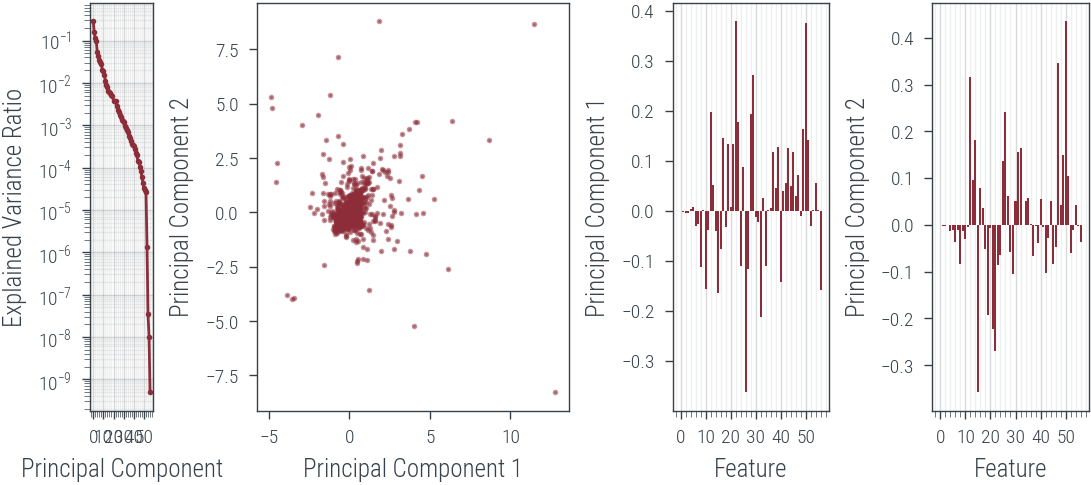

In [ ]:
def PCA(X, n_components=2, whiten=False):
    """
    Perform Principal Component Analysis (PCA) on the input data matrix X.

    Parameters:
        X: numpy.ndarray
            The input data matrix with shape (n_samples, p_features).
        n_components: int, optional
            The number of principal components to return. Default is 2.

    Returns:
        scores: numpy.ndarray
            The principal component scores with shape (n_samples, n_components).
        singular_values: numpy.ndarray
            The singular values of X.
        loadings: numpy.ndarray
            The loadings of X (that is, S @ V.T, the eigenvectors of X.T @ X multiplied by the square root of the eigenvalues).
        explained_variance_ratio: numpy.ndarray
            The explained variance ratio for each component.
    """
    # Center the data (subtract mean)
    X_centered = X - np.mean(X, axis=0)
    # Scale the data (divide by standard deviation, axis-wise)
    if whiten:
        X_centered = X_centered / np.std(X_centered, axis=0)

    # Compute singular value decomposition
    U, S, Vt = svds(
        X_centered, k=n_components, which="LM", return_singular_vectors=True
    )
    # svds returns U sorted from small to large. We need to reverse it:
    U = U[:, ::-1]
    S = S[::-1]
    Vt = Vt[::-1, :]
    scores = U @ np.diag(S)

    # alternative form of PCA, using the covariance matrix:
    X_cov = np.cov(X_centered, rowvar=False)
    S, Vt = np.linalg.eigh(X_cov)
    S = S[::-1]
    Vt = Vt[::-1, :]

    scores = X_centered @ Vt.T
    loadings = np.diag(S) @ Vt
    explained_variance_ratio = S**2 / np.sum(S**2)

    return scores, S, Vt, loadings, explained_variance_ratio


X_pca, S, Vt, loadings, explained_variance_ratio = PCA(
    danish_for_dim_reduction, n_components=10, whiten=True
)

# Plot the explained variance ratio
fig, axs = plt.subplots(1, 4, width_ratios=[0.2, 1, 0.5, 0.5])
ax = axs[0]
ax.plot(explained_variance_ratio, "o-", color=rgb.tue_red, ms=1)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_yscale("log")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
ax.yaxis.set_major_locator(plt.LogLocator(base=10, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10, subs="all", numticks=10))
ax.grid(which="major", color=rgb.tue_dark)
ax.grid(which="minor", color=rgb.tue_gray)

ax = axs[1]
ax.plot(X_pca[:, 0], X_pca[:, 1], ".", color=rgb.tue_red, ms=2, alpha=0.5)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

for i in 0, 1:
    ax = axs[2 + i]
    ax.bar(range(len(Vt[i, :])), Vt[i, :])
    ax.set_ylabel(f"Principal Component {i+1}")
    ax.set_xlabel("Feature")
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
    ax.grid(which="major", color=rgb.tue_dark, axis="x")
    ax.grid(which="minor", color=rgb.tue_gray, axis="x")

    plt.savefig("PCA_danish.pdf")

Once again, we need an interactive version of this plot

In [219]:
# Danish PCA plot
fig_pca_danish = go.Figure(
    data=go.Scatter(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        mode="markers",
        marker=dict(
            size=4, opacity=0.7, color=color_from_rgb(rgb.tue_blue), line=dict(width=0)
        ),
        text=Danish["FoodName"],
        hovertemplate="<b>%{text}</b><br>"
        + "PC1: %{x:.2f}<br>"
        + "PC2: %{y:.2f}<br>"
        + "<extra></extra>",
    ),
)

fig_pca_danish.update_layout(
    title="PCA: Danish Food Data",
    xaxis_title=f"PC1 ({explained_variance_ratio[0]*100:.1f}% variance)",
    yaxis_title=f"PC2 ({explained_variance_ratio[1]*100:.1f}% variance)",
    template=custom_template,
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

# Show both plots
fig_pca_danish.show()

PCA is pretty pointless. Instead, let's try 

## $t$-SNE

In [ ]:
# we'll us a library. openTSNE is a fast implementation of t-SNE, co-developed here in Tübingen.
import openTSNE

tsne = openTSNE.TSNE(
    perplexity=30, metric="euclidean", n_jobs=-1, random_state=42, verbose=True
)
danish_tsne_result = tsne.fit(danish_for_dim_reduction)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=-1, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.12 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.03 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=114.17 for 250 iterations...
Iteration   50, KL divergence 2.6743, 50 iterations in 1.0819 sec
Iteration  100, KL divergence 2.7211, 50 iterations in 1.0225 sec
Iteration  150, KL divergence 2.7207, 50 iterations in 1.5448 sec
Iteration  200, KL divergence 2.7207, 50 iterations in 1.0273 sec
Iteration  250, KL divergence 2.7208, 50 iterations in 1.0304 sec
   --> Time elapsed: 5.71 seconds
===> Running optimization with exaggeration=1

In [ ]:
# Create interactive t-SNE plot
fig_tsne = go.Figure(
    data=go.Scatter(
        x=danish_tsne_result[:, 0],
        y=danish_tsne_result[:, 1],
        mode="markers",
        marker=dict(
            size=4, opacity=0.7, color=color_from_rgb(rgb.tue_blue), line=dict(width=0)
        ),
        text=Danish["FoodName"],
        hovertemplate="<b>%{text}</b><br>"
        + "t-SNE1: %{x:.2f}<br>"
        + "t-SNE2: %{y:.2f}<br>"
        + "<extra></extra>",
    ),
)

fig_tsne.update_layout(
    title="t-SNE: FRIDA",
    xaxis_title="t-SNE1",
    yaxis_title="t-SNE2",
    template=custom_template,
    showlegend=False,
    width=plotly_width,
    height=plotly_height,
)

fig_tsne.show()

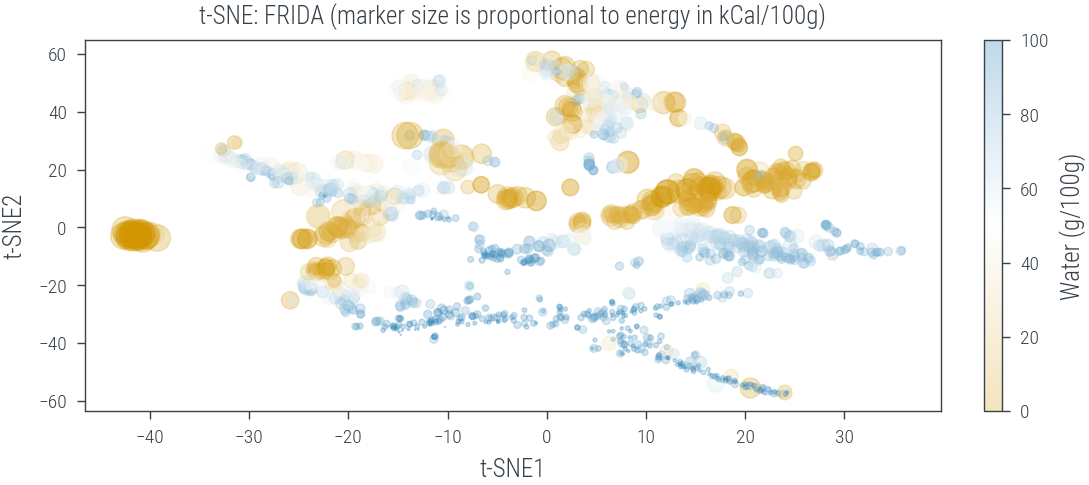

In [ ]:
# and a plot for the slides:
fig, ax = plt.subplots()
s1 = ax.scatter(
    x=danish_tsne_result[:, 0],
    y=danish_tsne_result[:, 1],
    c=Danish["Water"],
    cmap=LinearSegmentedColormap.from_list(
        "owb", [rgb.tue_orange, "w", rgb.tue_blue], N=1024
    ),
    s=Danish["Energy (kcal)"] / 10,
    alpha=0.25,
)
ax.set_xlabel("t-SNE1")
ax.set_ylabel("t-SNE2")
ax.set_title("t-SNE: FRIDA (marker size is proportional to energy in kCal/100g)")
fig.colorbar(s1, label="Water (g/100g)")

plt.savefig("t-SNE_FRIDA_water_energy.pdf")

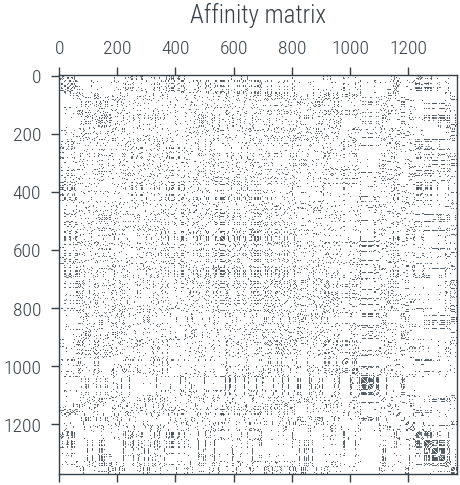

In [ ]:
# as a diagnostic, we also plot the affinity matrix in the high-dimensional space, and the low-dimensional embedding:
plt.rcParams.update(bundles.beamer_moml(rel_width=0.5))
P = danish_tsne_result.affinities.P.toarray()
danish_tsne_result.kl_divergence
# d2 = np.sum((danish_for_dim_reduction[:,None,:] - danish_for_dim_reduction[None,:,:])**2, axis=2)
# P = np.exp(-d2 / 2 / sigma**2)
# P = P / np.sum(P - np.eye(P.shape[0])*P, axis=1, keepdims=True)

fig, ax = plt.subplots()
ax.matshow(np.log10(P + np.finfo(float).eps), cmap=cmap_wd)
ax.set_title("Affinity matrix")
plt.savefig("t-SNE_FRIDA_affinity_matrix.pdf")